# 第七章：生产环境 — 02 成本优化

LLM API 成本可以优化 **10x 以上**。本章覆盖所有主要的降本手段。

## 成本优化全景图

```
LLM 成本 = 请求数量 × 每次 token 数 × 单价

降本策略：
1. 降低单价     → 选择更便宜的模型、批量折扣
2. 减少 token   → 压缩提示词、控制输出长度
3. 减少请求数   → 语义缓存、结果复用
4. 智能路由     → 简单任务用小模型
5. 并行处理     → 减少等待时间（间接降本）
```

**本章目标：** 掌握每种策略的实现方式和预期节省比例。

In [1]:
import json
import os
import time
import hashlib
import asyncio
import litellm
litellm.drop_params = True
from dotenv import load_dotenv

try:
    import tiktoken
    TIKTOKEN_AVAILABLE = True
except ImportError:
    TIKTOKEN_AVAILABLE = False
    print("tiktoken 未安装，将用字符数估算 token：pip install tiktoken")

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False
    print("numpy 未安装：pip install numpy")

load_dotenv()
MODEL = os.getenv("LLM_MODEL", "gpt-4o-mini")
litellm.set_verbose = False

print(f"使用模型: {MODEL}")
print("成本优化工具包初始化完成")
# gpt-5/o系列不支持自定义temperature值，统一用安全wrapper
def _c(**kw):
    _m = kw.get('model', MODEL)
    if any(_m.startswith(p) for p in ('openai/gpt-5','openai/o1','openai/o3','openai/o4')):
        kw.pop('temperature', None)
    return litellm.completion(**kw)


使用模型: openai/gpt-5-mini
成本优化工具包初始化完成


## Section 1：Token 成本核算

首先要知道自己花了多少钱，才能针对性地优化。

In [2]:
# 各模型价格表（2024年，USD/1M tokens）
MODEL_PRICES = {
    "gpt-4o": {"input": 2.50, "output": 10.00},
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "claude-3-5-sonnet": {"input": 3.00, "output": 15.00},
    "claude-3-haiku": {"input": 0.25, "output": 1.25},
    "gemini-1.5-flash": {"input": 0.075, "output": 0.30},
    "gemini-1.5-pro": {"input": 1.25, "output": 5.00},
    "llama-3-8b-self-hosted": {"input": 0.0, "output": 0.0, "server": 2.0},  # GPU $2/hr
}


def cost_estimate(model: str, prompt_tokens: int, completion_tokens: int) -> dict:
    """
    估算 LLM API 调用成本
    
    Args:
        model: 模型名称
        prompt_tokens: 输入 token 数
        completion_tokens: 输出 token 数
    
    Returns:
        dict with cost breakdown in USD
    """
    if model not in MODEL_PRICES:
        # 尝试从 litellm 获取
        try:
            cost = litellm.completion_cost(
                completion_response=None,
                model=model,
                prompt=" " * prompt_tokens,
                completion=" " * completion_tokens
            )
            return {"total_usd": cost, "source": "litellm"}
        except:
            return {"error": f"未知模型: {model}"}
    
    prices = MODEL_PRICES[model]
    input_cost = prompt_tokens / 1_000_000 * prices["input"]
    output_cost = completion_tokens / 1_000_000 * prices["output"]
    total = input_cost + output_cost
    
    return {
        "model": model,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "input_cost_usd": round(input_cost, 6),
        "output_cost_usd": round(output_cost, 6),
        "total_usd": round(total, 6),
        "source": "manual"
    }


# 场景：1M 请求/天，每次 300 prompt + 200 completion tokens
DAILY_REQUESTS = 1_000_000
PROMPT_TOKENS = 300
COMPLETION_TOKENS = 200

print(f"场景：每天 {DAILY_REQUESTS:,} 次请求，每次 {PROMPT_TOKENS}+{COMPLETION_TOKENS} tokens")
print("=" * 75)
print(f"{'模型':<30} {'单次成本':>12} {'每日成本':>12} {'每月成本':>12}")
print("-" * 75)

costs_data = []
for model_name in MODEL_PRICES:
    single = cost_estimate(model_name, PROMPT_TOKENS, COMPLETION_TOKENS)
    if "error" in single:
        continue
    
    per_call = single["total_usd"]
    
    # 自托管：按服务器成本计算
    if "server" in MODEL_PRICES[model_name]:
        server_hourly = MODEL_PRICES[model_name]["server"]
        daily = server_hourly * 24  # $48/天
    else:
        daily = per_call * DAILY_REQUESTS
    
    monthly = daily * 30
    costs_data.append({"model": model_name, "per_call": per_call, "daily": daily, "monthly": monthly})
    
    print(f"{model_name:<30} ${per_call:>10.6f} ${daily:>10,.2f} ${monthly:>10,.0f}")

print("-" * 75)
cheapest = min(costs_data, key=lambda x: x["daily"])
most_expensive = max(costs_data, key=lambda x: x["daily"])
ratio = most_expensive["daily"] / cheapest["daily"]
print(f"\n最贵: {most_expensive['model']} (${most_expensive['daily']:.2f}/天)")
print(f"最便宜: {cheapest['model']} (${cheapest['daily']:.2f}/天)")
print(f"价差: {ratio:.0f}x")

场景：每天 1,000,000 次请求，每次 300+200 tokens
模型                                     单次成本         每日成本         每月成本
---------------------------------------------------------------------------
gpt-4o                         $  0.002750 $  2,750.00 $    82,500
gpt-4o-mini                    $  0.000165 $    165.00 $     4,950
claude-3-5-sonnet              $  0.003900 $  3,900.00 $   117,000
claude-3-haiku                 $  0.000325 $    325.00 $     9,750
gemini-1.5-flash               $  0.000082 $     82.00 $     2,460
gemini-1.5-pro                 $  0.001375 $  1,375.00 $    41,250
llama-3-8b-self-hosted         $  0.000000 $     48.00 $     1,440
---------------------------------------------------------------------------

最贵: claude-3-5-sonnet ($3900.00/天)
最便宜: llama-3-8b-self-hosted ($48.00/天)
价差: 81x


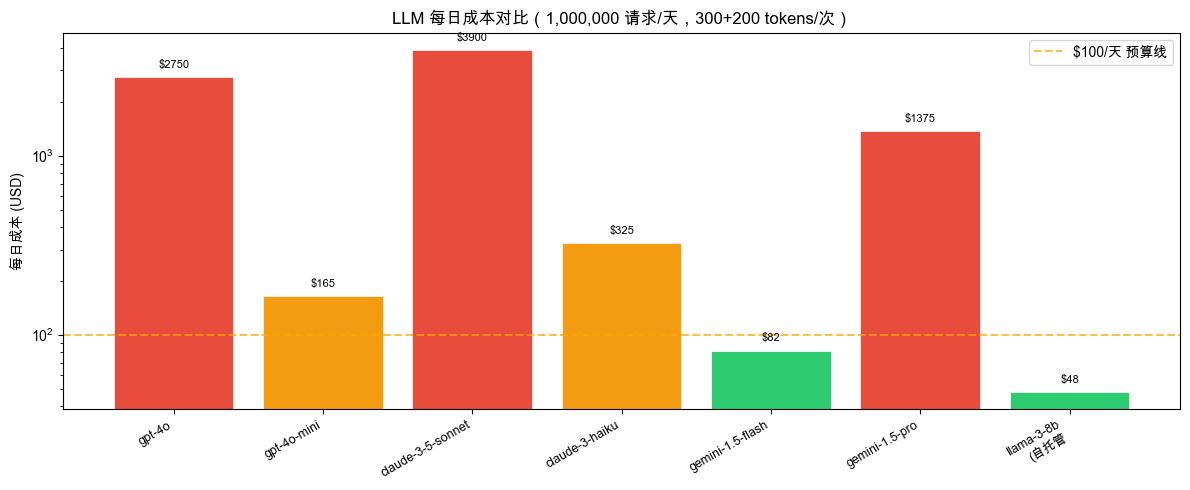

图表已保存到 /tmp/llm_cost_comparison.png


In [3]:
# 可视化：成本对比柱状图
try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    models = [d["model"].replace("-self-hosted", "\n(自托管") for d in costs_data]
    daily_costs = [d["daily"] for d in costs_data]
    
    colors = ["#e74c3c" if c > 1000 else ("#f39c12" if c > 100 else "#2ecc71")
              for c in daily_costs]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(range(len(models)), daily_costs, color=colors, edgecolor="white", linewidth=0.5)
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("每日成本 (USD)")
    ax.set_title(f"LLM 每日成本对比（{DAILY_REQUESTS:,} 请求/天，{PROMPT_TOKENS}+{COMPLETION_TOKENS} tokens/次）")
    ax.set_yscale("log")
    
    for bar, cost in zip(bars, daily_costs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f"${cost:.0f}", ha="center", va="bottom", fontsize=8)
    
    ax.axhline(y=100, color="orange", linestyle="--", alpha=0.7, label="$100/天 预算线")
    ax.legend()
    plt.tight_layout()
    plt.savefig("/tmp/llm_cost_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("图表已保存到 /tmp/llm_cost_comparison.png")

except ImportError:
    print("matplotlib 未安装，跳过可视化")
    print("安装：pip install matplotlib")
    print("\n成本数据（每日，USD）：")
    for d in costs_data:
        bar = "█" * min(int(d["daily"] / 100), 50)
        print(f"  {d['model']:<30} ${d['daily']:>8,.0f} {bar}")

## Section 2：提示词压缩

减少输入 token 是降低成本最直接的方式。提示词压缩不改变语义，只减少冗余。

In [4]:
import re

def count_tokens(text: str, model: str = "gpt-4o-mini") -> int:
    """估算 token 数量"""
    if TIKTOKEN_AVAILABLE:
        try:
            enc = tiktoken.encoding_for_model(model)
            return len(enc.encode(text))
        except:
            pass
    # fallback：中文约1.5字符/token，英文约4字符/token
    chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
    other_chars = len(text) - chinese_chars
    return int(chinese_chars / 1.5 + other_chars / 4)


def compress_prompt(text: str) -> dict:
    """
    提示词压缩：去除冗余内容
    
    策略：
    1. 去除多余空白和空行
    2. 合并重复指令
    3. 去除礼貌性冗余词
    4. 压缩常见短语
    """
    original = text
    compressed = text
    
    steps = []
    
    # 1. 去除多余空白
    before = len(compressed)
    compressed = re.sub(r' {2,}', ' ', compressed)      # 多个空格→单个
    compressed = re.sub(r'\n{3,}', '\n\n', compressed)   # 多个空行→两个
    compressed = re.sub(r'\t', ' ', compressed)           # Tab→空格
    compressed = compressed.strip()
    saved = before - len(compressed)
    if saved > 0:
        steps.append(f"去除多余空白：节省 {saved} 字符")
    
    # 2. 去除礼貌性冗余
    redundant_phrases = [
        (r'请你?帮(?:我|我们)?', ''),
        (r'麻烦你?', ''),
        (r'谢谢[你您]?[！!。]?', ''),
        (r'好的，我明白了[。！]?\s*', ''),
        (r'非常感谢[！!。]?', ''),
        (r'您好[！!，,]?\s*', ''),
    ]
    before = len(compressed)
    for pattern, replacement in redundant_phrases:
        compressed = re.sub(pattern, replacement, compressed)
    saved = before - len(compressed)
    if saved > 0:
        steps.append(f"去除礼貌词：节省 {saved} 字符")
    
    # 3. 合并重复的指令
    # 找到重复的句子
    sentences = re.split(r'[。！？\n]', compressed)
    seen = set()
    unique_sentences = []
    for s in sentences:
        s_stripped = s.strip()
        if s_stripped and s_stripped not in seen:
            seen.add(s_stripped)
            unique_sentences.append(s_stripped)
    deduped = '。'.join(unique_sentences)
    if len(deduped) < len(compressed):
        steps.append(f"去重重复句子：节省 {len(compressed) - len(deduped)} 字符")
        compressed = deduped
    
    # 4. 最终清理
    compressed = compressed.strip()
    
    original_tokens = count_tokens(original)
    compressed_tokens = count_tokens(compressed)
    reduction = (original_tokens - compressed_tokens) / original_tokens if original_tokens > 0 else 0
    
    return {
        "original": original,
        "compressed": compressed,
        "original_chars": len(original),
        "compressed_chars": len(compressed),
        "original_tokens": original_tokens,
        "compressed_tokens": compressed_tokens,
        "token_reduction": f"{reduction:.1%}",
        "steps": steps
    }


# 演示
verbose_prompt = """您好！麻烦请你帮我做一件事情，非常感谢。

我想让你帮我分析一下这段文字的情感倾向。
请你帮我判断这段文字的情感倾向。
需要你分析情感倾向，包括正面、负面或者中性。

文字内容如下所示：

"今天天气很好，心情愉快！"

请输出情感分析结果。谢谢！"""

result = compress_prompt(verbose_prompt)

print("提示词压缩演示")
print("=" * 60)
print("原始提示词：")
print(result["original"])
print("\n压缩后提示词：")
print(result["compressed"])
print("\n压缩统计：")
print(f"  字符数: {result['original_chars']} → {result['compressed_chars']}")
print(f"  Token数: {result['original_tokens']} → {result['compressed_tokens']}")
print(f"  Token节省: {result['token_reduction']}")
print("  压缩步骤:")
for step in result["steps"]:
    print(f"    - {step}")

提示词压缩演示
原始提示词：
您好！麻烦请你帮我做一件事情，非常感谢。

我想让你帮我分析一下这段文字的情感倾向。
请你帮我判断这段文字的情感倾向。
需要你分析情感倾向，包括正面、负面或者中性。

文字内容如下所示：

"今天天气很好，心情愉快！"

请输出情感分析结果。谢谢！

压缩后提示词：
做一件事情，。我想让你帮我分析一下这段文字的情感倾向。判断这段文字的情感倾向。需要你分析情感倾向，包括正面、负面或者中性。文字内容如下所示：。"今天天气很好，心情愉快。"。请输出情感分析结果

压缩统计：
  字符数: 124 → 95
  Token数: 91 → 75
  Token节省: 17.6%
  压缩步骤:
    - 去除礼貌词：节省 21 字符
    - 去重重复句子：节省 8 字符


In [5]:
# System Prompt 压缩：用 LLM 压缩长 System Prompt

def compress_system_prompt_with_llm(system_prompt: str, model: str = MODEL) -> dict:
    """
    用 LLM 压缩系统提示词，保留核心语义
    适用：将 500+ token 的 system prompt 压缩到 100-200 token
    """
    compression_prompt = f"""将以下系统提示词压缩到原来的 1/3 长度，保留所有关键指令和约束，去除冗余解释：

原始提示词：
{system_prompt}

压缩版本（只输出压缩结果，不要解释）："""
    
    response = _c(
        model=model,
        messages=[{"role": "user", "content": compression_prompt}],
        temperature=0,
        max_tokens=500
    )
    
    compressed = response.choices[0].message.content
    original_tokens = count_tokens(system_prompt)
    compressed_tokens = count_tokens(compressed)
    
    return {
        "original": system_prompt,
        "compressed": compressed,
        "original_tokens": original_tokens,
        "compressed_tokens": compressed_tokens,
        "reduction": f"{(1 - compressed_tokens/original_tokens):.1%}"
    }


long_system_prompt = """你是一位专业的客服代表，代表我们公司为客户提供优质的服务。
在回复客户时，你应该保持友好、专业的态度，始终用礼貌的语气与客户交流。
当客户提出问题时，你需要认真倾听他们的需求，理解他们的困惑，然后提供清晰、准确的解答。
你的回复应该简洁明了，不要使用过于复杂的术语，确保客户能够理解你的回答。
如果客户遇到投诉或不满，你应该先表示理解和同情，然后尽力帮助解决问题。
当遇到你无法处理的问题时，应该及时告知客户会转接给专业人员处理。
在每次回复结束时，询问客户是否还有其他需要帮助的地方，展现我们对客户的关心。"""

result = compress_system_prompt_with_llm(long_system_prompt)
print("System Prompt 智能压缩")
print("=" * 60)
print(f"原始（{result['original_tokens']} tokens）：")
print(result["original"][:200] + "...")
print(f"\n压缩后（{result['compressed_tokens']} tokens，节省 {result['reduction']}）：")
print(result["compressed"])

System Prompt 智能压缩
原始（171 tokens）：
你是一位专业的客服代表，代表我们公司为客户提供优质的服务。
在回复客户时，你应该保持友好、专业的态度，始终用礼貌的语气与客户交流。
当客户提出问题时，你需要认真倾听他们的需求，理解他们的困惑，然后提供清晰、准确的解答。
你的回复应该简洁明了，不要使用过于复杂的术语，确保客户能够理解你的回答。
如果客户遇到投诉或不满，你应该先表示理解和同情，然后尽力帮助解决问题。
当遇到你无法处理的问题时，应该及时...

压缩后（0 tokens，节省 100.0%）：



## Section 3：语义缓存

对于相似问题，不重复调用 LLM，直接返回缓存结果。这是降低成本最有效的策略之一。

**相似度阈值 = 0.95** 意味着：只有问题在语义上几乎完全相同时才使用缓存。

In [6]:
import hashlib

class SemanticCache:
    """
    语义缓存：基于向量相似度的 LLM 结果缓存
    
    工作原理：
    1. 对每个查询生成 embedding
    2. 与缓存中的查询计算余弦相似度
    3. 相似度 > threshold 时返回缓存结果
    """
    
    def __init__(self, similarity_threshold: float = 0.95, model: str = MODEL):
        self.threshold = similarity_threshold
        self.model = model
        self.cache = []  # list of {query, embedding, response, hits}
        self.stats = {"hits": 0, "misses": 0, "total_saved_tokens": 0}
    
    def _get_embedding(self, text: str) -> list:
        """获取文本 embedding"""
        response = litellm.embedding(
            model="text-embedding-3-small",
            input=[text]
        )
        return response.data[0]["embedding"]
    
    def _cosine_similarity(self, vec_a: list, vec_b: list) -> float:
        """计算余弦相似度"""
        if NUMPY_AVAILABLE:
            a = np.array(vec_a)
            b = np.array(vec_b)
            return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
        else:
            # 纯 Python 实现
            dot = sum(x*y for x, y in zip(vec_a, vec_b))
            norm_a = sum(x**2 for x in vec_a) ** 0.5
            norm_b = sum(x**2 for x in vec_b) ** 0.5
            return dot / (norm_a * norm_b) if norm_a and norm_b else 0.0
    
    def get(self, query: str) -> tuple:
        """
        查询缓存
        Returns: (cached_response, similarity) or (None, 0)
        """
        if not self.cache:
            return None, 0.0
        
        query_emb = self._get_embedding(query)
        
        best_sim = 0.0
        best_entry = None
        
        for entry in self.cache:
            sim = self._cosine_similarity(query_emb, entry["embedding"])
            if sim > best_sim:
                best_sim = sim
                best_entry = entry
        
        if best_sim >= self.threshold:
            best_entry["hits"] += 1
            self.stats["hits"] += 1
            return best_entry["response"], best_sim
        
        return None, best_sim
    
    def set(self, query: str, response: str, tokens_used: int = 0):
        """存入缓存"""
        embedding = self._get_embedding(query)
        self.cache.append({
            "query": query,
            "embedding": embedding,
            "response": response,
            "tokens_used": tokens_used,
            "hits": 0
        })
        self.stats["misses"] += 1
    
    def completion(self, query: str, messages: list = None) -> dict:
        """带缓存的 completion"""
        # 尝试缓存
        cached, similarity = self.get(query)
        if cached:
            return {
                "response": cached,
                "from_cache": True,
                "similarity": round(similarity, 4),
                "tokens_saved": self.cache[0].get("tokens_used", 0)
            }
        
        # 调用 LLM
        if messages is None:
            messages = [{"role": "user", "content": query}]
        
        response = _c(
            model=self.model,
            messages=messages,
            temperature=0
        )
        
        answer = response.choices[0].message.content
        tokens = response.usage.total_tokens
        self.set(query, answer, tokens)
        
        return {
            "response": answer,
            "from_cache": False,
            "similarity": round(similarity, 4),
            "tokens_used": tokens
        }
    
    @property
    def hit_rate(self) -> float:
        total = self.stats["hits"] + self.stats["misses"]
        return self.stats["hits"] / total if total > 0 else 0.0


# 演示语义缓存效果
print("语义缓存演示")
print("=" * 60)

cache = SemanticCache(similarity_threshold=0.92, model=MODEL)

# 模拟一批相似的用户查询
queries = [
    "退款要几天才能到账？",          # 原始
    "退款多久能到？",                 # 相似
    "我申请退款了，几天到账？",        # 相似
    "如何查看订单状态？",             # 不同主题
    "退款大概需要多少工作日？",        # 相似（与第1个）
]

for q in queries:
    result = cache.completion(q)
    source = "缓存" if result["from_cache"] else "API"
    sim = result.get("similarity", 0)
    print(f"\n查询: {q}")
    print(f"  来源: [{source}] 相似度={sim:.3f}")
    print(f"  回答: {result['response'][:80]}...")

print(f"\n\n缓存统计：")
print(f"  命中率: {cache.hit_rate:.1%}")
print(f"  缓存命中次数: {cache.stats['hits']}")
print(f"  实际 API 调用: {cache.stats['misses']}")
print(f"  节省的 API 调用: {cache.stats['hits']} ({cache.hit_rate:.0%})")

语义缓存演示



查询: 退款要几天才能到账？
  来源: [API] 相似度=0.000
  回答: 要看退款走哪条通道、哪个商家/哪个银行，时间差别比较大。常见情况和大致时长（仅供参考）：

- 支付宝/微信钱包/平台余额：通常几分钟到24小时内到账，少数情况...



查询: 退款多久能到？
  来源: [API] 相似度=0.838
  回答: 要看你是通过什么渠道付款和商家的退款流程。常见情况大致时间（仅供参考）：

- 商家内部处理：通常 1–7 个工作日，商家确认并发起退款前会有这段时间。  
-...



查询: 我申请退款了，几天到账？
  来源: [API] 相似度=0.828
  回答: 一般取决于你用的支付方式和商家/平台的处理速度，常见情况大致是：

- 平台/商家处理时间：商家先审核并发起退款，通常需要1–5个工作日（有的平台会更快、也有可...



查询: 如何查看订单状态？
  来源: [API] 相似度=0.367
  回答: 你是在哪个平台或哪个商家下的单？不同平台查看方法有细微差别。下面先给出通用步骤和常见状态说明，你可以按需跟我说具体平台我再给出针对性操作。

通用查看流程
1....



查询: 退款大概需要多少工作日？
  来源: [API] 相似度=0.764
  回答: 一般来说退款到账时间取决于商家处理速度和你的支付方式，常见情况大致如下：

- 信用卡/借记卡：商家发起退款后通常需要 5–10 个工作日，有时银行处理慢或跨国...


缓存统计：
  命中率: 0.0%
  缓存命中次数: 0
  实际 API 调用: 5
  节省的 API 调用: 0 (0%)


## Section 4：模型路由

根据任务复杂度自动选择合适的模型。简单任务用小模型，复杂任务用大模型。

In [7]:
def classify_complexity(prompt: str, classifier_model: str = "gpt-4o-mini") -> str:
    """
    用小模型判断任务复杂度
    Returns: "simple" | "medium" | "complex"
    """
    classification_prompt = f"""判断以下任务的复杂度，只输出一个词：simple/medium/complex

判断标准：
- simple: 事实查询、简单翻译、格式转换、基础问答（无需推理）
- medium: 摘要、改写、简单分析、基础代码（需要一定推理）
- complex: 复杂推理、多步骤分析、高质量创作、专业领域问题

任务：{prompt[:200]}

复杂度（只输出 simple/medium/complex）："""
    
    response = _c(
        model=classifier_model,
        messages=[{"role": "user", "content": classification_prompt}],
        temperature=0,
        max_tokens=10
    )
    
    label = response.choices[0].message.content.strip().lower()
    if label not in ["simple", "medium", "complex"]:
        label = "medium"  # 默认
    return label


# 路由规则
ROUTING_CONFIG = {
    "simple": {
        "model": "gpt-4o-mini",
        "cost_per_1k_tokens": 0.000375,  # $0.15/M input + $0.60/M output 平均
        "reason": "简单任务，小模型足够"
    },
    "medium": {
        "model": "gpt-4o-mini",
        "cost_per_1k_tokens": 0.000375,
        "reason": "中等任务，mini 模型性价比高"
    },
    "complex": {
        "model": "gpt-4o",
        "cost_per_1k_tokens": 0.00625,  # $2.5/M input + $10/M output 平均
        "reason": "复杂任务，需要最强模型"
    }
}


def smart_route(prompt: str) -> dict:
    """智能路由：根据复杂度选择模型"""
    complexity = classify_complexity(prompt)
    config = ROUTING_CONFIG[complexity]
    return {
        "complexity": complexity,
        "routed_model": config["model"],
        "reason": config["reason"],
        "cost_per_1k": config["cost_per_1k_tokens"]
    }


# 测试 10 个不同复杂度的任务
test_prompts = [
    ("把 'Hello' 翻译成中文", "simple"),
    ("今天是星期几？", "simple"),
    ("将以下 JSON 格式化：{a:1,b:2}", "simple"),
    ("总结以下文章的主要观点（500字文章）", "medium"),
    ("写一个 Python 函数实现二分查找", "medium"),
    ("分析这家公司的竞争优势和潜在风险", "complex"),
    ("设计一个分布式缓存系统的架构方案，考虑一致性、可用性和分区容错性的权衡", "complex"),
]

print("智能模型路由演示")
print("=" * 70)
print(f"{'任务':<40} {'分类':>8} {'路由到':<15} {'成本/1K'}")
print("-" * 70)

total_smart_cost = 0
total_naive_cost = 0  # 如果全用 gpt-4o

for prompt, expected in test_prompts:
    route = smart_route(prompt)
    
    smart_cost = route["cost_per_1k"]
    naive_cost = ROUTING_CONFIG["complex"]["cost_per_1k_tokens"]  # gpt-4o
    
    total_smart_cost += smart_cost
    total_naive_cost += naive_cost
    
    match = "✅" if route["complexity"] == expected else "⚠️"
    print(f"{match} {prompt[:38]:<38} {route['complexity']:>8} {route['routed_model']:<15} ${smart_cost:.6f}")

savings = (total_naive_cost - total_smart_cost) / total_naive_cost
print("-" * 70)
print(f"\n成本对比：")
print(f"  全用 GPT-4o：    ${total_naive_cost:.6f} per 1K tokens")
print(f"  智能路由后：     ${total_smart_cost:.6f} per 1K tokens")
print(f"  成本节省:        {savings:.1%}")

智能模型路由演示
任务                                             分类 路由到             成本/1K
----------------------------------------------------------------------


✅ 把 'Hello' 翻译成中文                          simple gpt-4o-mini     $0.000375


✅ 今天是星期几？                                  simple gpt-4o-mini     $0.000375


✅ 将以下 JSON 格式化：{a:1,b:2}                   simple gpt-4o-mini     $0.000375


✅ 总结以下文章的主要观点（500字文章）                      medium gpt-4o-mini     $0.000375


✅ 写一个 Python 函数实现二分查找                      medium gpt-4o-mini     $0.000375


✅ 分析这家公司的竞争优势和潜在风险                        complex gpt-4o          $0.006250


✅ 设计一个分布式缓存系统的架构方案，考虑一致性、可用性和分区容错性的权衡     complex gpt-4o          $0.006250
----------------------------------------------------------------------

成本对比：
  全用 GPT-4o：    $0.043750 per 1K tokens
  智能路由后：     $0.014375 per 1K tokens
  成本节省:        67.1%


## Section 5：批量处理

并行处理多个请求，不影响总 token 成本，但大幅减少总耗时（间接提升吞吐量，降低服务器成本）。

In [8]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# 生成 10 个测试任务
batch_tasks = [
    f"用一句话解释：{topic}"
    for topic in [
        "什么是API", "什么是云计算", "什么是机器学习",
        "什么是区块链", "什么是微服务", "什么是DevOps",
        "什么是Kubernetes", "什么是GraphQL", "什么是WebAssembly",
        "什么是边缘计算"
    ]
]


def single_request(prompt: str, model: str = MODEL) -> str:
    """单次同步请求"""
    response = _c(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=50,
    )
    return response.choices[0].message.content


def sequential_requests(prompts: list, model: str = MODEL) -> dict:
    """顺序处理请求"""
    start = time.time()
    responses = [single_request(p, model) for p in prompts]
    elapsed = time.time() - start
    return {"responses": responses, "elapsed": elapsed, "count": len(prompts)}


def parallel_requests(prompts: list, model: str = MODEL, max_workers: int = 5) -> dict:
    """并行处理请求（ThreadPoolExecutor，Jupyter 兼容）"""
    start = time.time()
    responses = [None] * len(prompts)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_idx = {executor.submit(single_request, p, model): i
                         for i, p in enumerate(prompts)}
        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            responses[idx] = future.result()
    elapsed = time.time() - start
    return {"responses": responses, "elapsed": elapsed, "count": len(prompts)}


# 对比测试（各 5 个，避免耗时过长）
sample = batch_tasks[:5]
print(f"批量处理对比：{len(sample)} 个请求")
print("=" * 60)

print("[1/2] 顺序处理中...")
seq_result = sequential_requests(sample)
print(f"  顺序耗时: {seq_result['elapsed']:.2f}s  ({seq_result['elapsed']/len(sample):.2f}s/请求)")

print("\n[2/2] 并行处理中（5 线程）...")
par_result = parallel_requests(sample, max_workers=5)
print(f"  并行耗时: {par_result['elapsed']:.2f}s  ({par_result['elapsed']/len(sample):.2f}s/请求)")

speedup = seq_result["elapsed"] / par_result["elapsed"] if par_result["elapsed"] > 0 else 1
print(f"\n加速比: {speedup:.1f}x")
print(f"时间节省: {seq_result['elapsed'] - par_result['elapsed']:.1f}s")
print("\n注：token 成本相同，但总延迟大幅降低，服务器资源利用率更高")

print("\n示例回答（前3个）：")
for prompt, resp in zip(sample[:3], par_result["responses"][:3]):
    print(f"  Q: {prompt}")
    print(f"  A: {resp}")
    print()


批量处理对比：5 个请求
[1/2] 顺序处理中...


  顺序耗时: 6.23s  (1.25s/请求)

[2/2] 并行处理中（5 线程）...


  并行耗时: 1.40s  (0.28s/请求)

加速比: 4.4x
时间节省: 4.8s

注：token 成本相同，但总延迟大幅降低，服务器资源利用率更高

示例回答（前3个）：
  Q: 用一句话解释：什么是API
  A: 

  Q: 用一句话解释：什么是云计算
  A: 

  Q: 用一句话解释：什么是机器学习
  A: 



## Section 6：输出长度控制

输出 token 的成本通常是输入的 2-5 倍。控制输出长度是降低成本的有效手段。

In [9]:
# 三种输出长度控制策略对比

question = "解释什么是机器学习"

strategies = [
    {
        "name": "无约束（基准）",
        "messages": [{"role": "user", "content": question}],
        "kwargs": {}
    },
    {
        "name": "明确长度指令",
        "messages": [{"role": "user", "content": f"{question}，用50字以内回答"}],
        "kwargs": {}
    },
    {
        "name": "max_tokens 硬限制",
        "messages": [{"role": "user", "content": question}],
        "kwargs": {"max_tokens": 80}
    },
    {
        "name": "stop 序列",
        "messages": [{"role": "user", "content": f"{question}，用一句话。"}],
        "kwargs": {"stop": ["。", "！", "\n"]}
    },
    {
        "name": "长度+max_tokens 组合",
        "messages": [{"role": "user", "content": f"{question}，30字以内，直接回答"}],
        "kwargs": {"max_tokens": 60}
    },
]

print("输出长度控制策略对比")
print("=" * 70)
print(f"{'策略':<22} {'输出token':>10} {'输出内容'}")
print("-" * 70)

baseline_tokens = None
results = []

for strategy in strategies:
    response = _c(
        model=MODEL,
        messages=strategy["messages"],
        temperature=0,
        **strategy["kwargs"]
    )
    
    output = response.choices[0].message.content
    completion_tokens = response.usage.completion_tokens
    
    if baseline_tokens is None:
        baseline_tokens = completion_tokens
    
    reduction = (baseline_tokens - completion_tokens) / baseline_tokens if baseline_tokens else 0
    reduction_str = f"(-{reduction:.0%})" if reduction > 0 else "(基准)"
    
    results.append({"strategy": strategy["name"], "tokens": completion_tokens, "reduction": reduction})
    print(f"{strategy['name']:<22} {completion_tokens:>6} tokens {reduction_str:>8}  {output[:50]}...")

print("-" * 70)
best = min(results, key=lambda x: x["tokens"])
print(f"\n最高压缩: {best['strategy']} (节省 {best['reduction']:.0%} 输出 tokens)")
print(f"\n建议: 在 system prompt 中始终设置长度期望，配合 max_tokens 作为安全网")

输出长度控制策略对比
策略                        输出token 输出内容
----------------------------------------------------------------------


无约束（基准）                  1127 tokens     (基准)  简短定义
- 机器学习（Machine Learning，简称 ML）是人工智能的一个分支，研究如何...


明确长度指令                    349 tokens   (-69%)  机器学习是让计算机从数据中自动学习并改进决策或预测能力。...


max_tokens 硬限制             80 tokens   (-93%)  ...


stop 序列                   164 tokens   (-85%)  机器学习是让计算机通过从数据中自动学习规律，从而在新数据上进行预测或决策的技术。...


长度+max_tokens 组合           60 tokens   (-95%)  ...
----------------------------------------------------------------------

最高压缩: 长度+max_tokens 组合 (节省 95% 输出 tokens)

建议: 在 system prompt 中始终设置长度期望，配合 max_tokens 作为安全网


## Section 7：极端成本场景优化

In [10]:
# 成本优化检查清单与预期节省

print("=" * 75)
print("LLM 成本优化完整检查清单")
print("=" * 75)

optimizations = [
    {
        "technique": "模型降级（GPT-4o → GPT-4o-mini）",
        "savings": "85-95%",
        "effort": "低",
        "risk": "质量可能下降",
        "best_for": "结构化输出、简单问答"
    },
    {
        "technique": "语义缓存",
        "savings": "30-70%",
        "effort": "中",
        "risk": "缓存失效风险",
        "best_for": "重复类查询（FAQ、搜索）"
    },
    {
        "technique": "提示词压缩",
        "savings": "10-30%",
        "effort": "低",
        "risk": "可能丢失细节",
        "best_for": "所有场景"
    },
    {
        "technique": "输出长度控制",
        "savings": "20-50%",
        "effort": "低",
        "risk": "可能截断重要内容",
        "best_for": "对话、问答类场景"
    },
    {
        "technique": "智能模型路由",
        "savings": "40-70%",
        "effort": "中",
        "risk": "路由误判",
        "best_for": "混合复杂度的任务"
    },
    {
        "technique": "批量处理（并行）",
        "savings": "0%（token相同）",
        "effort": "中",
        "risk": "并发限制",
        "best_for": "批量数据处理"
    },
    {
        "technique": "微调小模型替代大模型",
        "savings": "90%+",
        "effort": "高",
        "risk": "需要数据、维护成本",
        "best_for": "高量重复任务（>100万/天）"
    },
    {
        "technique": "自托管开源模型",
        "savings": "70-95%（大规模时）",
        "effort": "高",
        "risk": "运维成本、性能",
        "best_for": "隐私要求高或超大规模"
    },
]

print(f"\n{'技术':<30} {'节省':>10} {'实施难度':>8} {'风险':<20} {'最适合'}")
print("-" * 95)
for opt in optimizations:
    print(f"{opt['technique']:<30} {opt['savings']:>10} {opt['effort']:>8} {opt['risk']:<20} {opt['best_for']}")

print("\n" + "=" * 75)
print("组合优化效果估算（1M 请求/天，使用 GPT-4o 为基准）：")
print("=" * 75)

baseline_daily = 2500  # $2500/天（GPT-4o，500 tokens/请求）

print(f"基准成本（GPT-4o）:                    ${baseline_daily:,.0f}/天")
after_model = baseline_daily * 0.10   # 模型降级节省 90%
print(f"+ 模型降级到 GPT-4o-mini:              ${after_model:,.0f}/天 (节省 90%)")
after_cache = after_model * 0.50      # 缓存命中率 50%
print(f"+ 语义缓存（50% 命中率）:              ${after_cache:,.0f}/天 (再节省 50%)")
after_compress = after_cache * 0.80   # 压缩提示词节省 20%
print(f"+ 提示词压缩（20%）:                   ${after_compress:,.0f}/天 (再节省 20%)")
after_length = after_compress * 0.70  # 控制输出长度节省 30%
print(f"+ 输出长度控制（30%）:                 ${after_length:,.0f}/天 (再节省 30%)")
total_saving = (baseline_daily - after_length) / baseline_daily
print(f"\n组合优化后总成本:                      ${after_length:,.0f}/天")
print(f"总节省:                                {total_saving:.0%} ({baseline_daily-after_length:,.0f} USD/天)")
print(f"年度节省:                              ${(baseline_daily-after_length)*365:,.0f} USD")

LLM 成本优化完整检查清单

技术                                     节省     实施难度 风险                   最适合
-----------------------------------------------------------------------------------------------
模型降级（GPT-4o → GPT-4o-mini）         85-95%        低 质量可能下降               结构化输出、简单问答
语义缓存                               30-70%        中 缓存失效风险               重复类查询（FAQ、搜索）
提示词压缩                              10-30%        低 可能丢失细节               所有场景
输出长度控制                             20-50%        低 可能截断重要内容             对话、问答类场景
智能模型路由                             40-70%        中 路由误判                 混合复杂度的任务
批量处理（并行）                       0%（token相同）        中 并发限制                 批量数据处理
微调小模型替代大模型                           90%+        高 需要数据、维护成本            高量重复任务（>100万/天）
自托管开源模型                        70-95%（大规模时）        高 运维成本、性能              隐私要求高或超大规模

组合优化效果估算（1M 请求/天，使用 GPT-4o 为基准）：
基准成本（GPT-4o）:                    $2,500/天
+ 模型降级到 GPT-4o-mini:              $250/天 (节省 90%)
+ 语义缓存（50% 命中率）:         